## Polynomial Linear Regression

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
# Generated Random data

X = np.random.rand(50, 1)

Y = (
    2.5*(X**7)               
    - 1.8*(X**6)
    + 1.2*(X**5)
    - 0.9*(X**4)
    + 0.4*(X**3)
    + 0.7*(X**2)
    - 0.5*X
    + 0.15*np.random.randn(50, 1)   # Gaussian noise
)
    

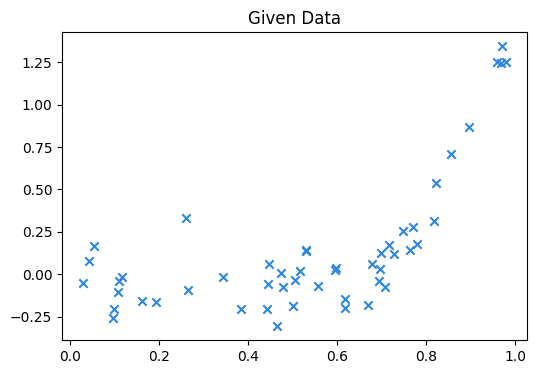

In [28]:
fig = plt.figure(figsize=(6,4))
plt.scatter(X,Y,color='#2E86DE', marker='x')
plt.title("Given Data")
plt.show()

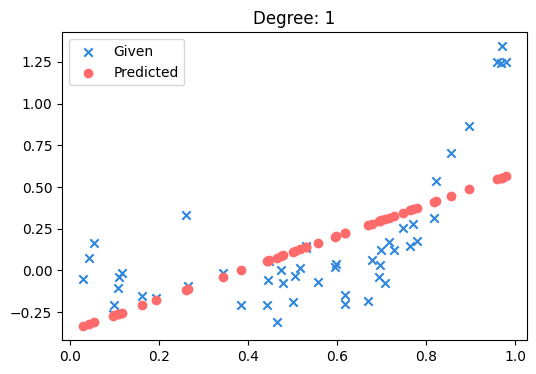

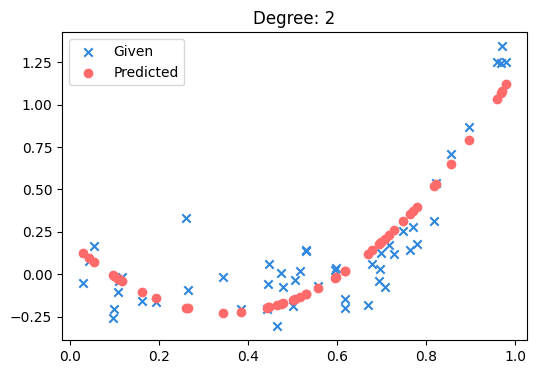

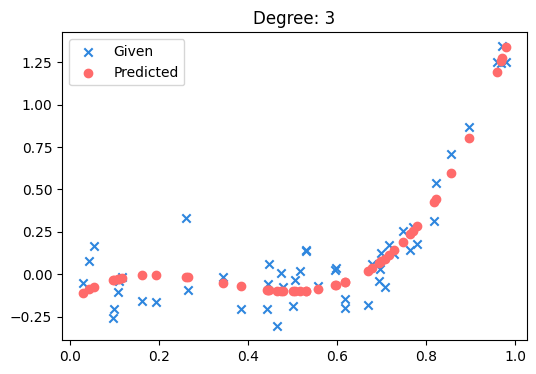

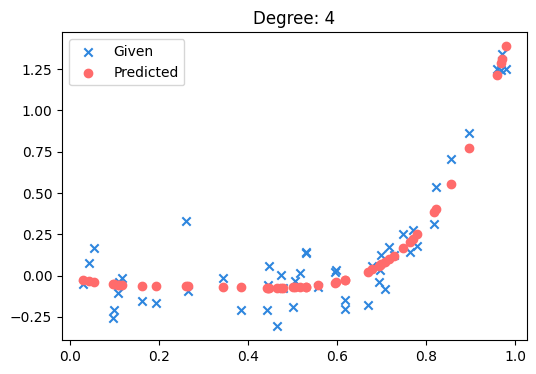

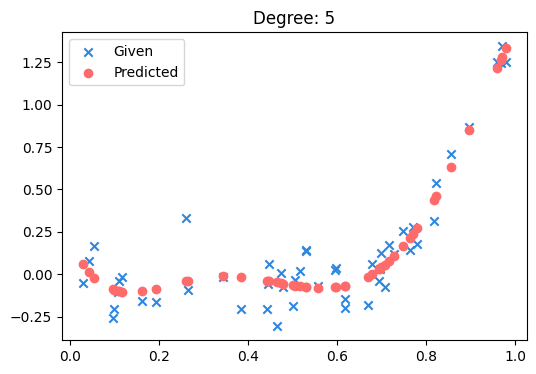

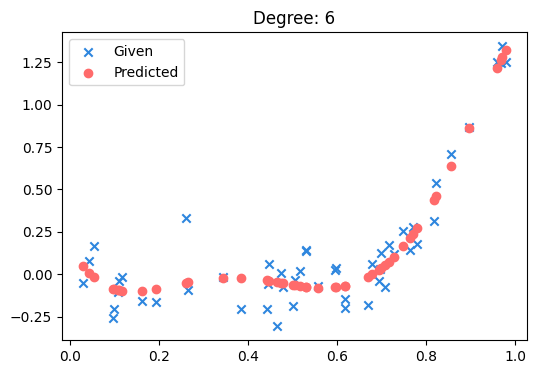

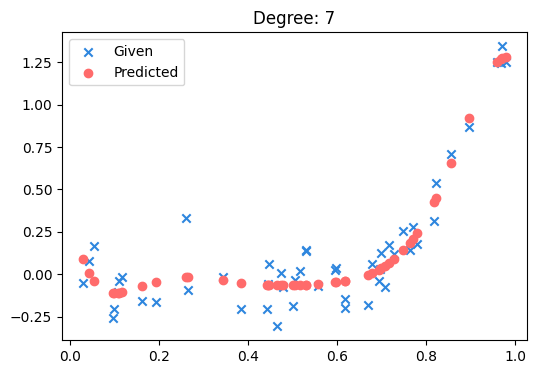

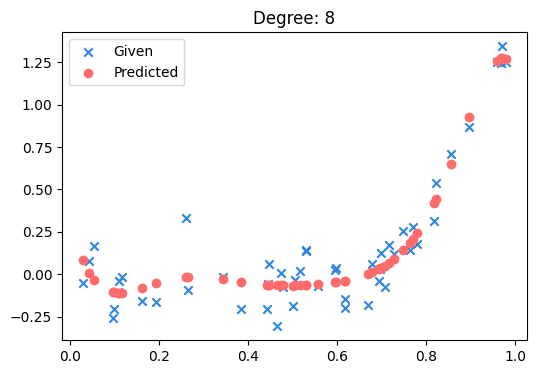

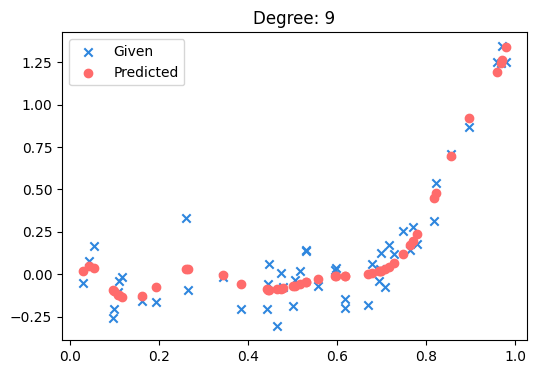

Degree 1 → MSE = 0.09463, R² = 0.41567
Degree 2 → MSE = 0.02930, R² = 0.81906
Degree 3 → MSE = 0.01636, R² = 0.89895
Degree 4 → MSE = 0.01529, R² = 0.90558
Degree 5 → MSE = 0.01391, R² = 0.91410
Degree 6 → MSE = 0.01389, R² = 0.91421
Degree 7 → MSE = 0.01336, R² = 0.91753
Degree 8 → MSE = 0.01334, R² = 0.91763
Degree 9 → MSE = 0.01240, R² = 0.92343


In [29]:

errors = []
degrees = range(1, 10)

for d in degrees:
  poly=PolynomialFeatures(d)
  x_poly = poly.fit_transform(X)
  scaler = StandardScaler()
  scaler.fit(x_poly)
  x_poly_stan = scaler.transform(x_poly)
  
  model = LinearRegression()
  model.fit(x_poly_stan,Y)
  output = model.predict(x_poly_stan)
  
  mse = mean_squared_error(Y, output)
  r2  = r2_score(Y, output)
  errors.append((d, mse, r2))
  
  fig = plt.figure(figsize=(6,4))
  plt.scatter(X,Y, label='Given', color='#2E86DE', marker='x')
  plt.scatter(X,output, label='Predicted', color='#FF6B6B')
  plt.title(f"Degree: {d}")
  plt.legend()
  plt.show()
  
for d, mse, r2 in errors:
  print(f"Degree {d} → MSE = {mse:.5f}, R² = {r2:.5f}")
  

#### Conclusion

✔ Best overall: Degree 4
- Very low MSE
- High R²
- Simple and smooth curve
- Least chance of overfitting

✔ Degree 5 is also acceptable
- Fits slightly better
- Still smooth
- Very small difference from degree 3

❌ degrees 6–9
They only chase noise and artificially reduce MSE.